<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/01_real_fastmri_zero_filled_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 97 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 47.81 KiB | 1.91 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [12]:
%cd reliability-aware-ssdu-mri

/content/reliability-aware-ssdu-mri/reliability-aware-ssdu-mri/reliability-aware-ssdu-mri


In [13]:
!ls

configs  docs	      LICENSE	 README.md  src
data	 experiments  notebooks  results    tests


**Connect Python to your src/ code**

In [14]:
import sys
sys.path.append("src")

from transforms import ifft2c
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range

print("Project code imported successfully.")

Project code imported successfully.


**Locate the saved fastMRI .h5 file in Drive**

In [15]:
!find /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted -name "*.h5" | head

/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_6001154.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_207_2070082.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_201_2010421.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1POST_202_6000343.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_2090032.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1_202_2020391.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_207_2070312.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1POST_202_6000291.h5
/content/drive/MyDri

**Load one real .h5 file cleanly**

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

with h5py.File(file_path, "r") as hf:
    print("Keys:", list(hf.keys()))
    print("Attributes:")
    for key, value in hf.attrs.items():
        print(key, ":", value)

    kspace = hf["kspace"][:]
    mask = hf["mask"][:]

print("K-space shape:", kspace.shape)
print("Mask shape:", mask.shape)
print("K-space dtype:", kspace.dtype)
print("Mask dtype:", mask.dtype)

Keys: ['ismrmrd_header', 'kspace', 'mask']
Attributes:
acceleration : 4
acquisition : AXT2
num_low_frequency : 32
patient_id : 2ec2dfc85e9ee10c4875af47b361957495df908a87d476f0603426ca93a5f2bc
K-space shape: (16, 16, 768, 396)
Mask shape: (396,)
K-space dtype: complex64
Mask dtype: float32


In [17]:
# Select central slice
slice_index = kspace.shape[0] // 2
kspace_slice = kspace[slice_index]

print("Selected slice index:", slice_index)
print("Selected k-space slice shape:", kspace_slice.shape)

# Zero-filled RSS reconstruction
zf_image = zero_filled_reconstruction(kspace_slice, mask=None, coil_axis=0)
zf_norm = normalize_to_unit_range(zf_image)

print("Reconstructed image shape:", zf_image.shape)
print("Min:", zf_image.min())
print("Max:", zf_image.max())

Selected slice index: 8
Selected k-space slice shape: (16, 768, 396)
Reconstructed image shape: (768, 396)
Min: 1.866878e-06
Max: 0.00045775695


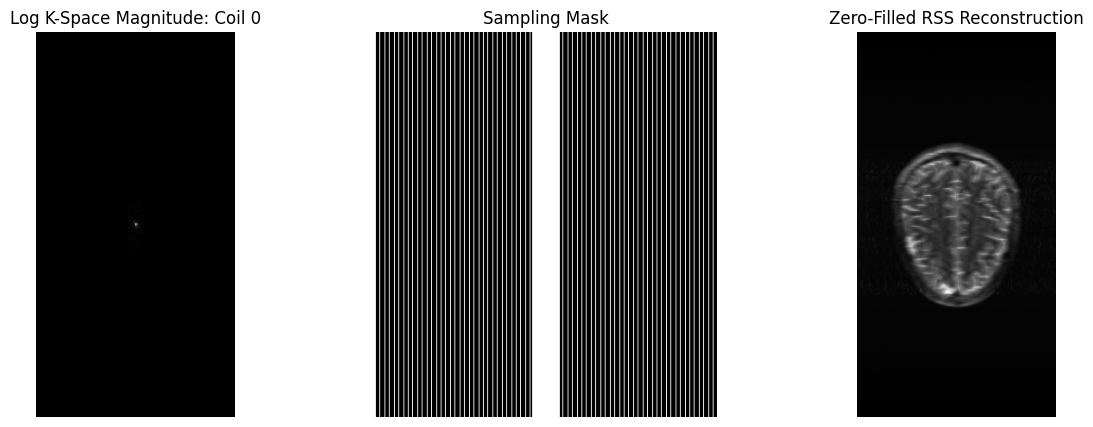

In [19]:
# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.log1p(np.abs(kspace_slice[0])), cmap="gray")
plt.title("Log K-Space Magnitude: Coil 0")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask[None, :], cmap="gray", aspect="auto")
plt.title("Sampling Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(zf_norm, cmap="gray")
plt.title("Zero-Filled RSS Reconstruction")
plt.axis("off")

plt.show()

#**Test src/fastmri_data.py in Colab**

**Pull latest GitHub changes**

In [33]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 958 bytes | 958.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   9561ec4..7707504  main       -> origin/main
Updating 9561ec4..7707504
Fast-forward
 src/{data.py => fastmri_data.py} | 0
 1 file changed, 0 insertions(+), 0 deletions(-)
 rename src/{data.py => fastmri_data.py} (100%)


In [34]:
!ls src












fastmri_data.py  masks.py    __pycache__  reconstruction.py
__init__.py	 metrics.py  README.md	  transforms.py


**Import the fastMRI data utilities**

In [35]:
import sys

# Add project source folder to Python path
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from fastmri_data import (
    load_fastmri_file,
    print_fastmri_summary,
    get_kspace_slice,
)

print("fastmri_data.py imported successfully.")

fastmri_data.py imported successfully.


**Load and inspect one fastMRI brain file**

In [36]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

print_fastmri_summary(data)

File path: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
Keys: ['ismrmrd_header', 'kspace', 'mask']

Attributes:
acceleration: 4
acquisition: AXT2
num_low_frequency: 32
patient_id: 2ec2dfc85e9ee10c4875af47b361957495df908a87d476f0603426ca93a5f2bc

K-space shape: (16, 16, 768, 396)
K-space dtype: complex64
Mask shape: (396,)
Mask dtype: float32


**Extract the central k-space slice**

In [37]:
kspace_slice, slice_index = get_kspace_slice(data["kspace"])

print("Selected slice index:", slice_index)
print("Selected k-space slice shape:", kspace_slice.shape)

Selected slice index: 8
Selected k-space slice shape: (16, 768, 396)


**Reconstruct using the reusable loader**

Zero-filled image shape: (768, 396)
Min intensity: 1.866878e-06
Max intensity: 0.00045775695


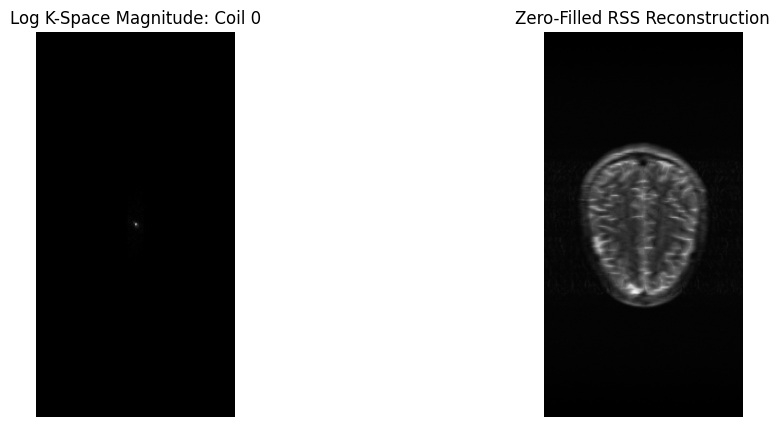

In [38]:
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range
import matplotlib.pyplot as plt
import numpy as np

zf_image = zero_filled_reconstruction(kspace_slice, mask=None, coil_axis=0)
zf_norm = normalize_to_unit_range(zf_image)

print("Zero-filled image shape:", zf_image.shape)
print("Min intensity:", zf_image.min())
print("Max intensity:", zf_image.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.log1p(np.abs(kspace_slice[0])), cmap="gray")
plt.title("Log K-Space Magnitude: Coil 0")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(zf_norm, cmap="gray")
plt.title("Zero-Filled RSS Reconstruction")
plt.axis("off")

plt.show()